Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Training superfast model...


Epoch 1/8:   0%|          | 0/5947 [00:00<?, ?it/s]


Epoch 1 Summary:
  ▸ Train Loss: 0.7404
  ▸ Val Dice:   0.5697
  ▸ Val IoU:    0.4979
  ▸ Val Acc:    0.8499

Model Saved: D:\coco2017\modeloutputs_mobilenet\best_mobilenetv3_unet.pth


Epoch 2/8:   0%|          | 0/5947 [00:00<?, ?it/s]

...


Epoch 6 Summary:
  ▸ Train Loss: 0.5000
  ▸ Val Dice:   0.5629
  ▸ Val IoU:    0.5077
  ▸ Val Acc:    0.8812



Epoch 7/8:   0%|          | 0/5947 [00:00<?, ?it/s]


Epoch 7 Summary:
  ▸ Train Loss: 0.4782
  ▸ Val Dice:   0.5468
  ▸ Val IoU:    0.4788
  ▸ Val Acc:    0.8683



Epoch 8/8:   0%|          | 0/5947 [00:00<?, ?it/s]


Epoch 8 Summary:
  ▸ Train Loss: 0.4604
  ▸ Val Dice:   0.5491
  ▸ Val IoU:    0.4855
  ▸ Val Acc:    0.8727

Saving predictions...


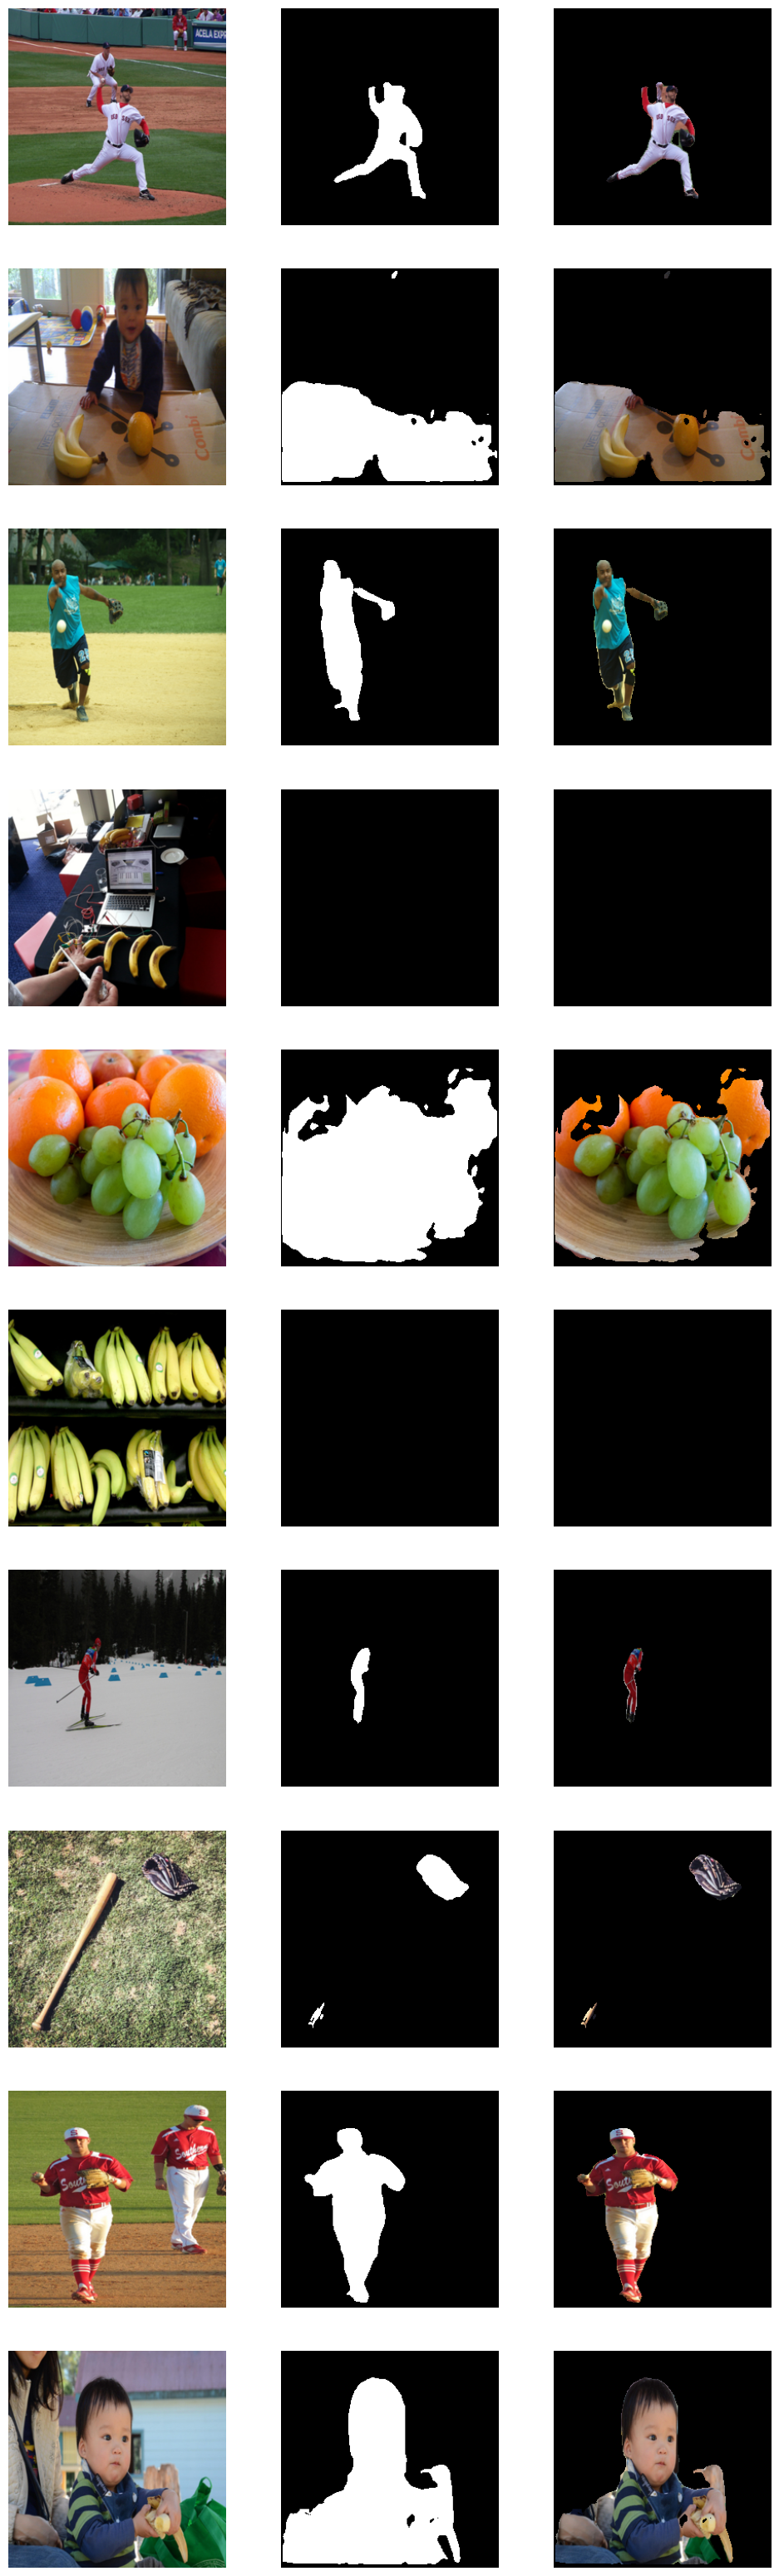

DONE ✔


In [1]:
# ============================================================
# SUPERFAST VERSION — MobileNetV3 UNet (GPU Safe)
# (ONLY ACCURACY ADDED)
# ============================================================

import os, re, random
from glob import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T

import segmentation_models_pytorch as smp


# CONFIG
IMG_DIR = r"D:\coco2017\Paired40k\images"
MASK_DIR = r"D:\coco2017\Paired40k\masks"
OUT_DIR = r"D:\coco2017\modeloutputs_mobilenet"

IMG_SIZE = 256
BATCH = 6
EPOCHS = 8
DEVICE = "cuda"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR,"predictions"), exist_ok=True)


# PAIR MATCHING
def extract_idx(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else None

imgs = sorted(glob(os.path.join(IMG_DIR, "*")))
masks = sorted(glob(os.path.join(MASK_DIR, "*")))

mask_map = { extract_idx(os.path.basename(m)): m for m in masks }

pairs = []
for im in imgs:
    idx = extract_idx(os.path.basename(im))
    if idx in mask_map:
        pairs.append((im, mask_map[idx]))

pairs = pairs[:40000]
train_len = int(0.9 * len(pairs))
train_pairs = pairs[:train_len]
val_pairs   = pairs[train_len:]


# DATASET
class CocoDS(Dataset):
    def __init__(self, pairs, size):
        self.pairs = pairs
        self.size = size

    def __len__(self): 
        return len(self.pairs)

    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        img = Image.open(ip).convert("RGB")
        msk = Image.open(mp).convert("L")

        img = TF.resize(img, self.size)
        msk = TF.resize(msk, self.size, interpolation=TF.InterpolationMode.NEAREST)

        img = TF.to_tensor(img)
        img = TF.normalize(img,[0.485,0.456,0.406],[0.229,0.224,0.225])

        msk = torch.tensor((np.array(msk)>127).astype(np.float32)).unsqueeze(0)

        return img, msk


train_loader = DataLoader(CocoDS(train_pairs,(IMG_SIZE,IMG_SIZE)),
                          batch_size=BATCH, shuffle=True)
val_loader = DataLoader(CocoDS(val_pairs,(IMG_SIZE,IMG_SIZE)),
                        batch_size=1)


# MODEL — MobileNetV3 UNet
model = smp.Unet(
    encoder_name="timm-mobilenetv3_large_100",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)


# LOSS
bce = nn.BCEWithLogitsLoss()

def dice(pred, mask):
    p = torch.sigmoid(pred)
    inter = (p * mask).sum()
    union = p.sum() + mask.sum()
    return (2*inter + 1) / (union + 1)

def iou(pred, mask):
    p = (torch.sigmoid(pred) > 0.5).float()
    g = mask
    inter = (p * g).sum()
    union = p.sum() + g.sum() - inter
    return (inter + 1) / (union + 1)

def accuracy(pred, mask):
    p = (torch.sigmoid(pred) > 0.5).float()
    return ((p == mask).float().mean()).item()

def total_loss(pred, mask):
    return bce(pred, mask) + (1 - dice(pred, mask))


# TRAIN
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

best_dice = 0
best_path = os.path.join(OUT_DIR, "best_mobilenetv3_unet.pth")

print("Training superfast model...")

for ep in range(1, EPOCHS+1):

    # ---------------- TRAIN ----------------
    model.train()
    total = 0
    pbar = tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}")

    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        opt.zero_grad()

        pred = model(imgs)
        loss = total_loss(pred, masks)
        loss.backward()
        opt.step()

        total += loss.item()
        pbar.set_postfix({"loss": total/len(train_loader)})

    train_loss = total / len(train_loader)


    # ---------------- VALIDATION ACCURACY ----------------
    model.eval()
    dsum = isum = asum = 0
    cnt = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            pred = model(imgs)

            dsum += dice(pred, masks).item()
            isum += iou(pred, masks).item()
            asum += accuracy(pred, masks)
            cnt += 1

    dval = dsum / cnt
    ival = isum / cnt
    aval = asum / cnt


    # PRINT ACCURACY
    print(f"\nEpoch {ep} Summary:")
    print(f"  ▸ Train Loss: {train_loss:.4f}")
    print(f"  ▸ Val Dice:   {dval:.4f}")
    print(f"  ▸ Val IoU:    {ival:.4f}")
    print(f"  ▸ Val Acc:    {aval:.4f}\n")


    # SAVE BEST MODEL
    if dval > best_dice:
        best_dice = dval
        torch.save(model.state_dict(), best_path)
        print("Model Saved:", best_path)


# =================================================
# INFERENCE SAVE (unchanged)
# =================================================

print("Saving predictions...")

save_dir = os.path.join(OUT_DIR,"predictions")
os.makedirs(save_dir, exist_ok=True)

for i in range(10):
    ip,mp = val_pairs[i]

    img = Image.open(ip).convert("RGB").resize((IMG_SIZE,IMG_SIZE))
    gt  = Image.open(mp).convert("L").resize((IMG_SIZE,IMG_SIZE))

    ten = TF.to_tensor(img)
    ten = TF.normalize(ten,[0.485,0.456,0.406],[0.229,0.224,0.225])
    ten = ten.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred=torch.sigmoid(model(ten))[0,0].cpu().numpy()

    pred_bin = (pred>0.5).astype(np.uint8)*255

    masked = np.zeros_like(np.array(img))
    masked[pred_bin>0] = np.array(img)[pred_bin>0]

    Image.fromarray(np.array(img)).save(f"{save_dir}/orig_{i}.png")
    Image.fromarray(pred_bin).save(f"{save_dir}/pred_{i}.png")
    Image.fromarray(masked).save(f"{save_dir}/masked_{i}.png")


# SHOW RESULTS
fig, ax = plt.subplots(10,3,figsize=(12,40))
for i in range(10):
    ax[i,0].imshow(Image.open(f"{save_dir}/orig_{i}.png")); ax[i,0].axis("off")
    ax[i,1].imshow(Image.open(f"{save_dir}/pred_{i}.png"),cmap="gray"); ax[i,1].axis("off")
    ax[i,2].imshow(Image.open(f"{save_dir}/masked_{i}.png")); ax[i,2].axis("off")

plt.show()
print("DONE ✔")
